# Titanic Survival Analysis

This notebook loads the Kaggle Titanic training data, creates initial passenger and family features, separates a validation set, handles missing values using training information, explores only the training data, and evaluates a baseline Random Forest classifier.


## 1. Load the dataset

The data is loaded into `full_df` so that relationship features can be identified before splitting passengers into training and validation sets.


In [2107]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA_DIR = Path("./data")
full_df = pd.read_csv(DATA_DIR / "train.csv")

print("Dataset shape:", full_df.shape)
full_df.head()


Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Kaggle Titanic Dataset Information

### Data Dictionary

| Variable      | Description                          | Values / Notes                                         |
| ------------- | ------------------------------------ | ------------------------------------------------------ |
| `PassengerId` | Unique passenger identifier          | Integer ID                                             |
| `Survived`    | Survival status                      | `0` = No, `1` = Yes                                    |
| `Pclass`      | Passenger ticket class               | `1` = First, `2` = Second, `3` = Third                 |
| `Name`        | Passenger name                       | Includes surname and title                             |
| `Sex`         | Passenger sex                        | `male`, `female`                                       |
| `Age`         | Age in years                         | Fractional for infants; estimated ages may end in `.5` |
| `SibSp`       | Number of siblings or spouses aboard | Includes siblings, step-siblings, husbands and wives   |
| `Parch`       | Number of parents or children aboard | Includes parents, children and stepchildren            |
| `Ticket`      | Ticket number                        | Alphanumeric identifier                                |
| `Fare`        | Passenger fare                       | Fare paid for the ticket                               |
| `Cabin`       | Cabin number                         | Contains many missing values                           |
| `Embarked`    | Port of embarkation                  | `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton   |

### Additional Notes

* `Pclass` can be treated as an approximate indicator of socioeconomic status:

  * `1` = Upper class
  * `2` = Middle class
  * `3` = Lower class
* `SibSp` includes brothers, sisters, stepbrothers, stepsisters, husbands and wives. Fiancés and mistresses were not counted.
* `Parch` includes mothers, fathers, daughters, sons, stepdaughters and stepsons.
* Some children travelled with a nanny rather than a parent, so they may have `Parch = 0`.


# 2. Feature Engineering

Feature engineering is performed **before the split** only for information that depends on relationships between passengers, such as detecting whether a spouse appears elsewhere in the dataset.


## Name column - Information we can gather

- Contains information about whether the person may be married. Titles like Mrs. or Miss.
- Titles can also indicate social status and age.
- For many married women, the name in parentheses is the woman's own or maiden name; the husband's given names usually appear after `Mrs.` outside the parentheses. We can use the naming convention, surname, ticket and `SibSp` logic to look for high-probability spouse matches.
- In the preprocessing, I will not use passengers from the Kaggle `test.csv` file. I will use the full `train.csv` file before the split, but the EDA itself will be preformed on the new training data, after the split.

At the end, we might discard created columns if it appears they don't contribute.


### Extracting Information from Title

First we want to work only on titles and surnames. Titles can indicate special status, age, or a likely married status. Surnames will help us find passengers who are spouses with higher probability later on.


In [2108]:
full_df["Title"] = (
    full_df["Name"]
    .str.extract(r",\s*([^.]*)\.", expand=False)
    .str.strip()
)

full_df["Surname"] = (
    full_df["Name"]
    .str.split(",")
    .str[0]
    .str.strip()
)

title_counts = full_df["Title"].value_counts(dropna=False)
display(title_counts.to_frame("Count"))


,Count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


### Title-based features

Titles provide compact information about likely marital status, age and uncommon professional or social status. `Mrs` and `Mme` indicate a likely married or widowed woman, while `Master` normally identifies a young boy. Rare professional, military, religious and noble titles are combined into one `SpecialTitle` feature.


Since there are very few special titles, I will combine them into one `SpecialTitle` feature. This reduces sparsity while preserving the information that a passenger held an uncommon title.


In [2109]:
full_df["IsMarried"] = full_df["Title"].isin(
    ["Mrs", "Mme"]
).astype(int)

full_df["IsChildTitle"] = full_df["Title"].eq(
    "Master"
).astype(int)

special_titles = [
    "Dr",
    "Rev",
    "Col",
    "Major",
    "Don",
    "Lady",
    "Sir",
    "Capt",
    "the Countess",
    "Jonkheer",
]

full_df["SpecialTitle"] = (
    full_df["Title"]
    .isin(special_titles)
    .astype(int)
)


### Shared-ticket features

Passengers sharing a ticket probably travelled under the same booking, although they were not necessarily relatives. `TicketGroupSize` retains the size of that travel group. Sharing both a ticket and surname is used as stronger, but still uncertain, evidence that another relative was aboard.


In [2110]:
full_df["TicketGroupSize"] = (
    full_df.groupby("Ticket")["PassengerId"]
    .transform("count")
)

full_df["PossibleRelativeOnBoard"] = (
    full_df.groupby(["Ticket", "Surname"])["PassengerId"]
    .transform("count")
    .gt(1)
    .astype(int)
)

display(
    full_df[
        ["TicketGroupSize", "PossibleRelativeOnBoard"]
    ].describe().T
)


,count,mean,std,min,25%,50%,75%,max
TicketGroupSize,891.0,1.787879,1.361142,1.0,1.0,1.0,2.0,7.0
PossibleRelativeOnBoard,891.0,0.281706,0.450083,0.0,0.0,0.0,1.0,1.0


### Finding married passengers

We'll look for couples who are on board together. For conventional `Mrs.` names, the part outside the parentheses often contains the husband's given names. We first try an exact reconstructed husband name. If that fails, we require one unique male candidate with the same surname and ticket, while both passengers have `SibSp > 0`.

This is a high-probability heuristic rather than confirmed ground truth.


The spouse columns start with no match. `SpousePassengerId` temporarily records the linked passenger so the relationship can be checked before identifiers are removed.


In [2111]:
full_df["SpouseOnBoard"] = 0
full_df["SpousePassengerId"] = pd.Series(
    pd.NA,
    index=full_df.index,
    dtype="Int64",
)


Potential husbands are identified using the strongest available evidence. Exact conventional name matching is preferred; the surname-ticket rule is used only when it produces one candidate.


In [2112]:
name_to_id = full_df.set_index("Name")["PassengerId"].to_dict()

wives = full_df[
    full_df["Title"].isin(["Mrs", "Mme"])
].copy()

wives["ExpectedHusbandName"] = (
    wives["Name"]
    .str.replace(r"\s*\([^()]*\)", "", regex=True)
    .str.replace(r",\s*(Mrs|Mme)\.", ", Mr.", regex=True)
    .str.strip()
)

couples = []

for _, wife in wives.iterrows():
    husband_id = name_to_id.get(wife["ExpectedHusbandName"])

    if husband_id is None:
        candidates = full_df[
            (full_df["Sex"] == "male")
            & (full_df["Surname"] == wife["Surname"])
            & (full_df["Ticket"] == wife["Ticket"])
            & (full_df["SibSp"] > 0)
            & (wife["SibSp"] > 0)
        ]

        if len(candidates) == 1:
            husband_id = candidates.iloc[0]["PassengerId"]

    if husband_id is not None:
        couples.append((wife["PassengerId"], husband_id))


If we found a match, `SpouseOnBoard` is changed to 1 for both passengers. The husband is also marked as married because `Mr.` alone does not reveal marital status.


In [2113]:
for wife_id, husband_id in couples:
    wife_mask = full_df["PassengerId"].eq(wife_id)
    husband_mask = full_df["PassengerId"].eq(husband_id)

    full_df.loc[wife_mask, "SpouseOnBoard"] = 1
    full_df.loc[wife_mask, "SpousePassengerId"] = husband_id

    full_df.loc[husband_mask, "IsMarried"] = 1
    full_df.loc[husband_mask, "SpouseOnBoard"] = 1
    full_df.loc[husband_mask, "SpousePassengerId"] = wife_id


The number of detected couples and affected passengers is reported separately. Each couple contributes two passengers to `SpouseOnBoard`.


In [2114]:
matched_passengers = int(full_df["SpouseOnBoard"].sum())

print("Couples found:", len(couples))
print("Passengers with a matched spouse:", matched_passengers)
print("Percentage of passengers:", round(matched_passengers / len(full_df) * 100, 2))


Couples found: 47
Passengers with a matched spouse: 94
Percentage of passengers: 10.55


### Fare transformation

Passenger fares are strongly right-skewed. `log1p` reduces that skew and safely handles zero fares by calculating `log(1 + Fare)`.


In [2115]:
full_df["Fare"] = np.log1p(full_df["Fare"])


# 3. Train/Validation Split

The complete DataFrame is split while retaining `Survived` in both subsets. Stratification keeps approximately the same survival rate in training and validation data.


In [2116]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=42,
    stratify=full_df["Survived"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_df:  ", val_df.shape)


train_df: (712, 21)
val_df:   (179, 21)


# 4. Initial Training-Data EDA

From this point, analytical decisions are based only on `train_df`. The validation set is transformed using rules learned from training data but is not explored for patterns.


The broad descriptive summary reveals distributions, missingness, unique values and potential problems across numeric and categorical features.


In [2117]:
train_df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,712.0,NaN,NaN,NaN,444.405899,257.465527,1.0,222.75,439.5,667.25,891.0
Survived,712.0,NaN,NaN,NaN,0.383427,0.486563,0.0,0.0,0.0,1.0,1.0
Pclass,712.0,NaN,NaN,NaN,2.308989,0.833563,1.0,2.0,3.0,3.0,3.0
Name,712,712,"Lam, Mr. Ali",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,712,2,male,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,575.0,NaN,NaN,NaN,29.807687,14.485211,0.42,21.0,28.5,39.0,80.0
SibSp,712.0,NaN,NaN,NaN,0.492978,1.06072,0.0,0.0,0.0,1.0,8.0
Parch,712.0,NaN,NaN,NaN,0.390449,0.838134,0.0,0.0,0.0,0.0,6.0
Ticket,712,571,1601,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,712.0,NaN,NaN,NaN,2.950802,0.97963,0.0,2.185579,2.737881,3.465736,6.240917


Remarks:

- Noticeable columns with missing values:
  - `Age`: about 21% missing. I will complete these using titles and passenger class.
  - `Cabin`: about 77% missing, with many distinct values. I will remove the column.
  - `Embarked`: only two missing records in the full Kaggle training data.
- The new columns, such as `SpecialTitle` or `IsChildTitle`, may prove useful. If they do not, I will remove them later.
- String-based columns will be retained temporarily because they help with age imputation and relationship features.


Category counts show the values and frequency of every string-based feature except `Name`, which has almost one unique value per passenger.


In [2118]:
categorical_columns = train_df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    if column != "Name":
        print(f"\n{column}")
        print(train_df[column].value_counts(dropna=False))



Sex
Sex
male      459
female    253
Name: count, dtype: int64

Ticket
Ticket
1601        6
347082      6
347088      5
3101295     5
CA. 2343    5
           ..
330935      1
31027       1
330980      1
111320      1
349257      1
Name: count, Length: 571, dtype: int64

Cabin
Cabin
NaN            552
G6               4
F33              3
F2               3
E101             3
              ... 
B51 B53 B55      1
C148             1
C49              1
C86              1
E63              1
Name: count, Length: 128, dtype: int64

Embarked
Embarked
S      516
C      139
Q       55
NaN      2
Name: count, dtype: int64

Title
Title
Mr          412
Miss        141
Mrs         107
Master       31
Dr            6
Rev           5
Mlle          2
Col           2
Major         1
Lady          1
Sir           1
Ms            1
Jonkheer      1
Don           1
Name: count, dtype: int64

Surname
Surname
Andersson    7
Sage         5
Skoog        5
Johnson      5
Panula       5
            ..
Renouf   

# 5. Handling Missing Values

`Cabin` is removed because most values are missing. The few missing `Embarked` values are filled with the most frequent training port so that validation rows are not discarded. The same training-derived value is used for validation.


In [2119]:
embarked_mode = train_df["Embarked"].mode()[0]

train_df["Embarked"] = train_df["Embarked"].fillna(embarked_mode)
val_df["Embarked"] = val_df["Embarked"].fillna(embarked_mode)

train_df.drop(columns="Cabin", inplace=True)
val_df.drop(columns="Cabin", inplace=True)


### Age imputation

We can use passenger titles because `Master`, `Miss`, `Mr` and `Mrs` carry information about typical age. Equivalent French titles are normalized before calculating age estimates.


In [2120]:
title_replacements = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
}

train_df["AgeTitle"] = train_df["Title"].replace(title_replacements)
val_df["AgeTitle"] = val_df["Title"].replace(title_replacements)


Median age is calculated for each title and passenger-class combination using only training data. The overall training median provides a fallback for any unseen or empty group.


In [2121]:
age_medians = train_df.groupby(
    ["AgeTitle", "Pclass"]
)["Age"].median()

overall_age_median = train_df["Age"].median()


The training-derived medians are mapped onto both datasets. This completes missing ages without learning any statistics from the validation set.


In [2122]:
def fill_age(df):
    estimated_age = df.set_index(
        ["AgeTitle", "Pclass"]
    ).index.map(age_medians)

    df["Age"] = df["Age"].fillna(
        pd.Series(estimated_age, index=df.index)
    ).fillna(overall_age_median)


fill_age(train_df)
fill_age(val_df)


The missing-value counts are checked before discarding temporary text columns. Both datasets should now contain no missing values in `Age` or `Embarked`.


In [2123]:
print("Train missing ages:", train_df["Age"].isna().sum())
print("Validation missing ages:", val_df["Age"].isna().sum())
print("Train missing embarkation:", train_df["Embarked"].isna().sum())
print("Validation missing embarkation:", val_df["Embarked"].isna().sum())


Train missing ages: 0
Validation missing ages: 0
Train missing embarkation: 0
Validation missing embarkation: 0


Now we can discard the high-cardinality text and identifier features that were used to create the engineered columns. `SpouseOnBoard` retains the useful relationship signal after `SpousePassengerId` is removed.


In [2124]:
columns_to_remove = [
    "Name",
    "Ticket",
    "Title",
    "Surname",
    "AgeTitle",
    "SpousePassengerId",
]

train_df.drop(columns=columns_to_remove, inplace=True)
val_df.drop(columns=columns_to_remove, inplace=True)


The cleaned numeric summary and missing-value check verify the result before the main EDA begins.


In [2125]:
display(train_df.describe().T)
display(
    train_df.isna()
    .sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
)


,count,mean,std,min,25%,50%,75%,max
PassengerId,712.0,444.405899,257.465527,1.00,222.750000,439.500000,667.250000,891.000000
Survived,712.0,0.383427,0.486563,0.00,0.000000,0.000000,1.000000,1.000000
Pclass,712.0,2.308989,0.833563,1.00,2.000000,3.000000,3.000000,3.000000
Age,712.0,29.398062,13.460508,0.42,21.000000,27.000000,38.000000,80.000000
SibSp,712.0,0.492978,1.060720,0.00,0.000000,0.000000,1.000000,8.000000
Parch,712.0,0.390449,0.838134,0.00,0.000000,0.000000,0.000000,6.000000
Fare,712.0,2.950802,0.979630,0.00,2.185579,2.737881,3.465736,6.240917
IsMarried,712.0,0.199438,0.399859,0.00,0.000000,0.000000,0.000000,1.000000
IsChildTitle,712.0,0.043539,0.204211,0.00,0.000000,0.000000,0.000000,1.000000
SpecialTitle,712.0,0.025281,0.157087,0.00,0.000000,0.000000,0.000000,1.000000


Series([], dtype: int64)

# 6. Training Data EDA

The remaining exploratory analysis uses only `train_df`. This protects the separate validation set from influencing feature decisions.


### Survival distribution

The target counts and percentages reveal whether the classes are balanced and provide a baseline for evaluating model accuracy.


In [2126]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

display(
    train_df["Survived"]
    .value_counts(dropna=False)
    .to_frame("Count")
    .assign(Percentage=lambda table: table["Count"] / len(train_df) * 100)
)


,Count,Percentage
Survived,,
0,439,61.657303
1,273,38.342697


### Column types

Low-cardinality columns are treated as categorical for EDA even when they are stored as integers. Continuous numeric columns are examined separately.


In [2127]:
categorical_columns = [
    column
    for column in train_df.columns
    if column != "Survived"
    and (
        train_df[column].dtype == "object"
        or train_df[column].nunique() <= 10
    )
]

numerical_columns = [
    column
    for column in train_df.select_dtypes(include="number").columns
    if column not in categorical_columns
    and column not in ["Survived", "PassengerId"]
]

print("Categorical:", categorical_columns)
print("Numerical:", numerical_columns)


Categorical: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'IsMarried', 'IsChildTitle', 'SpecialTitle', 'TicketGroupSize', 'PossibleRelativeOnBoard', 'SpouseOnBoard']
Numerical: ['Age', 'Fare']


## Numerical Column Distribution

Histograms show the shape, spread and skew of continuous features after the fare transformation and age imputation.


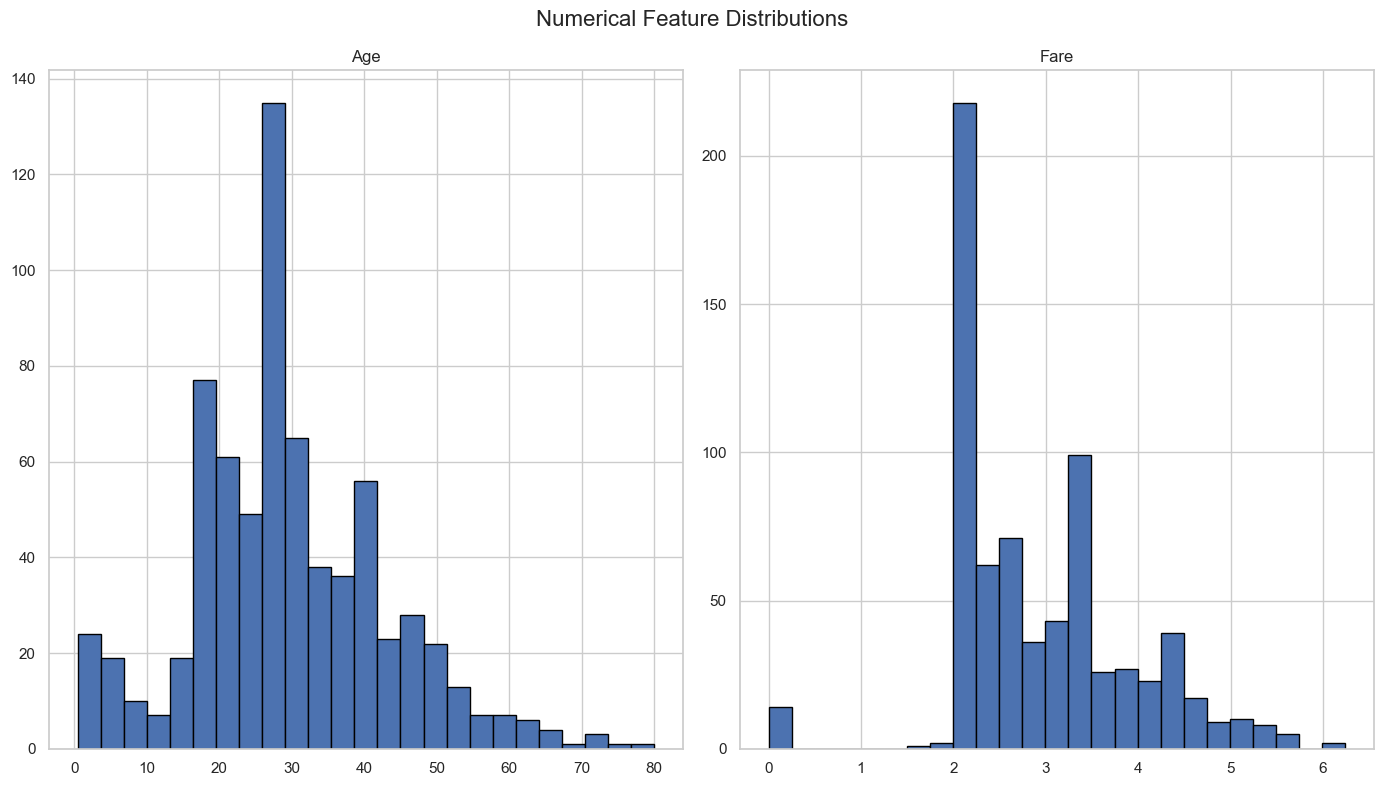

In [2128]:
train_df[numerical_columns].hist(
    figsize=(14, 8),
    bins=25,
    edgecolor="black",
)

plt.suptitle("Numerical Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()


Boxplots make extreme values and differences in scale easier to see than histograms alone.


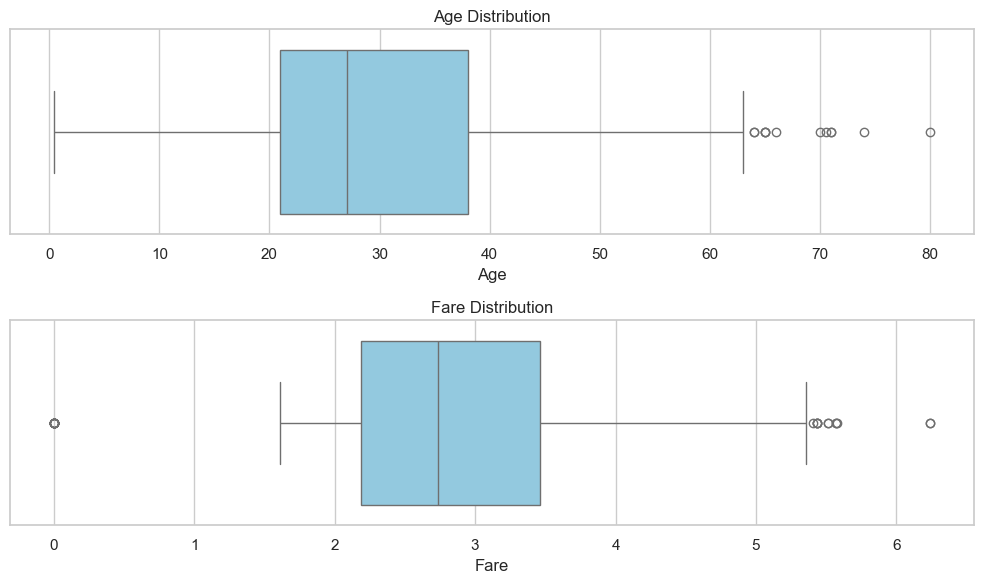

In [2129]:
fig, axes = plt.subplots(
    len(numerical_columns),
    1,
    figsize=(10, 3 * len(numerical_columns)),
)

if len(numerical_columns) == 1:
    axes = [axes]

for column, ax in zip(numerical_columns, axes):
    sns.boxplot(data=train_df, x=column, ax=ax, color="skyblue")
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()


## Categorical Column Distribution

Count plots reveal category imbalance and verify the frequency of engineered Boolean features.


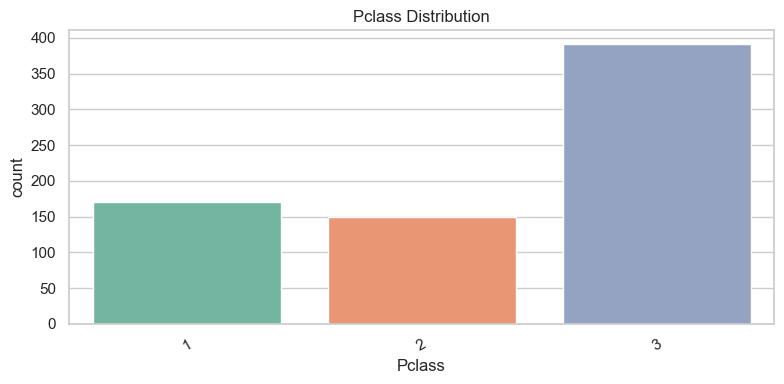

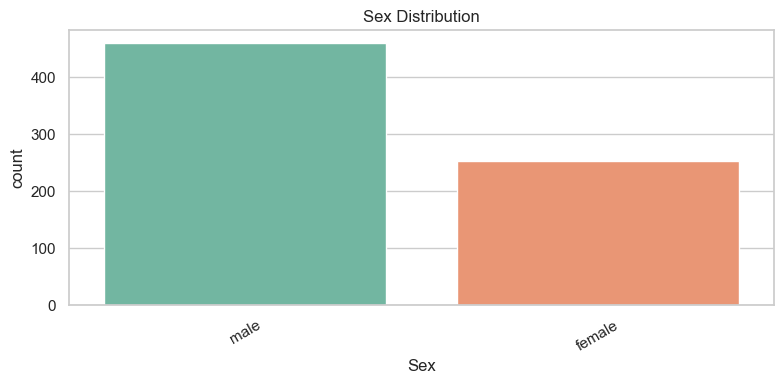

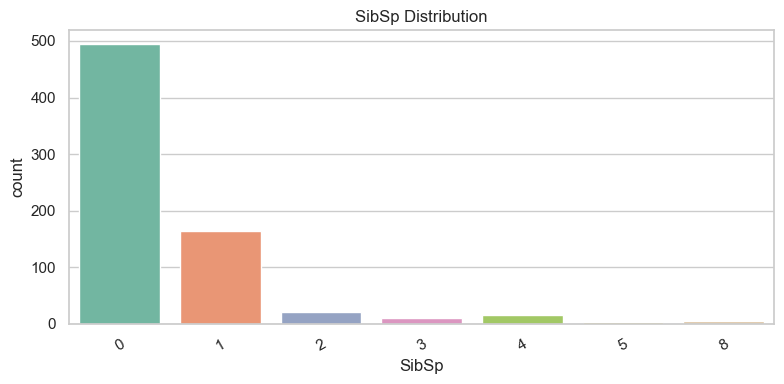

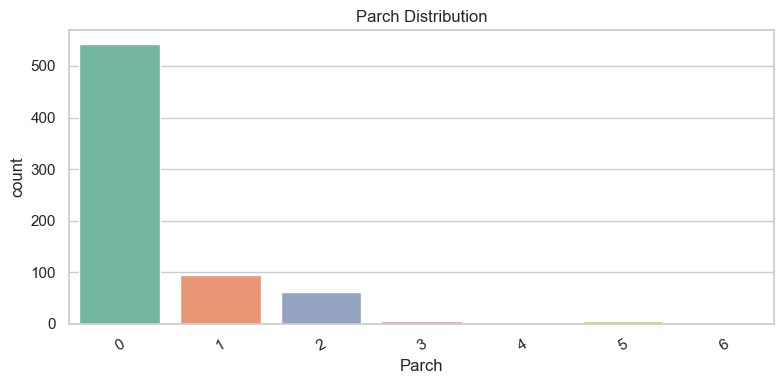

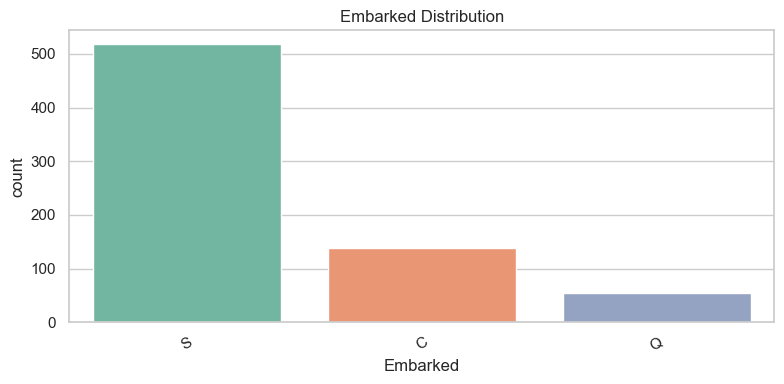

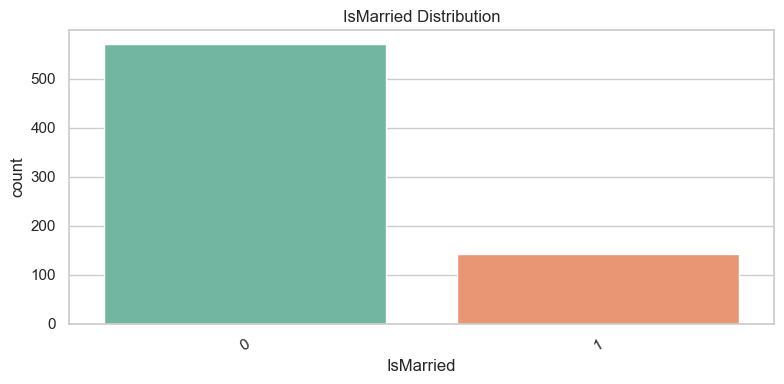

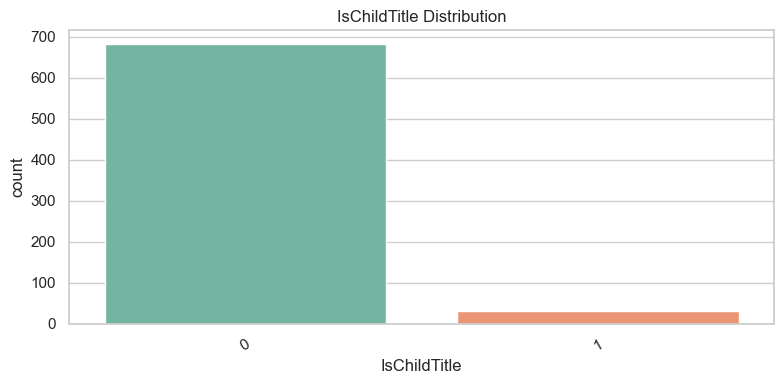

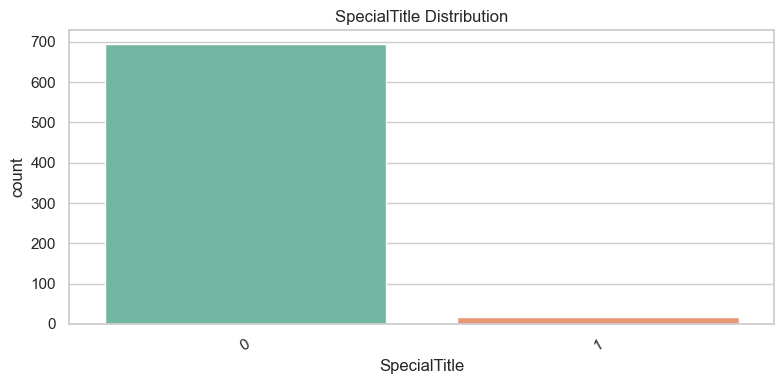

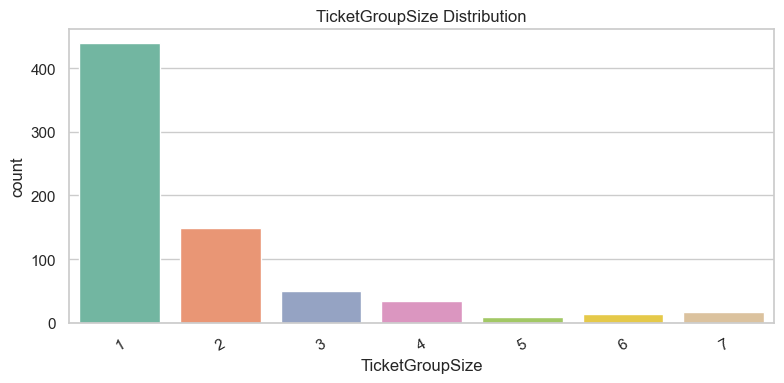

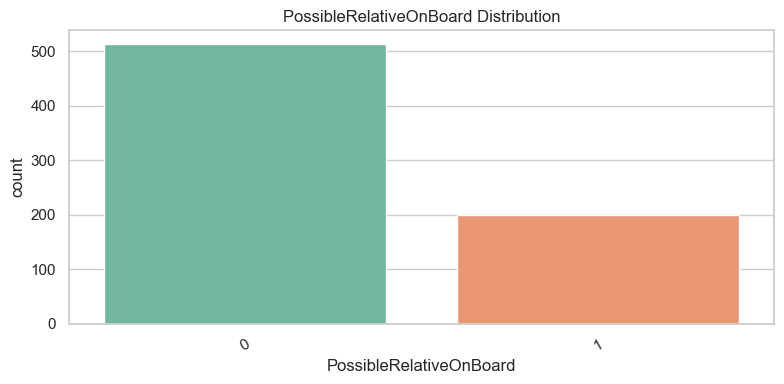

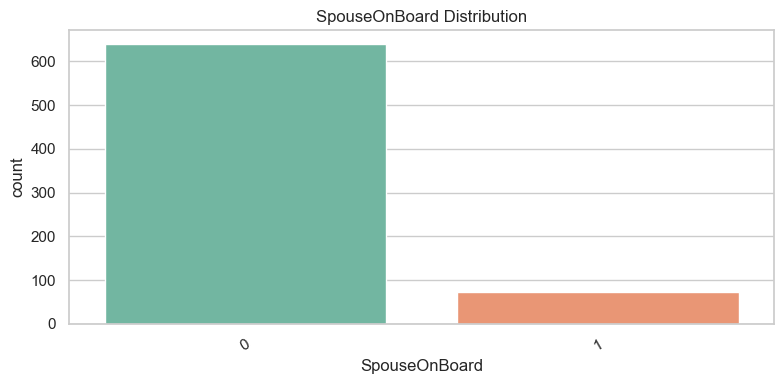

In [2130]:
for column in categorical_columns:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train_df,
        x=column,
        hue=column,
        legend=False,
        palette="Set2",
    )

    plt.title(f"{column} Distribution")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## Categorical Features and Survival

Splitting each category by `Survived` reveals which categories may be associated with the target.


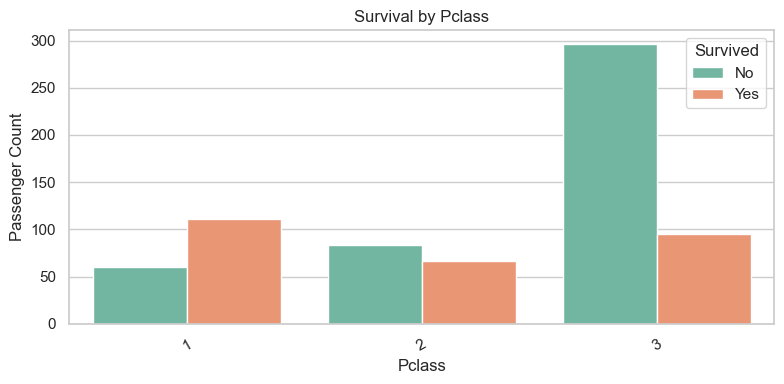

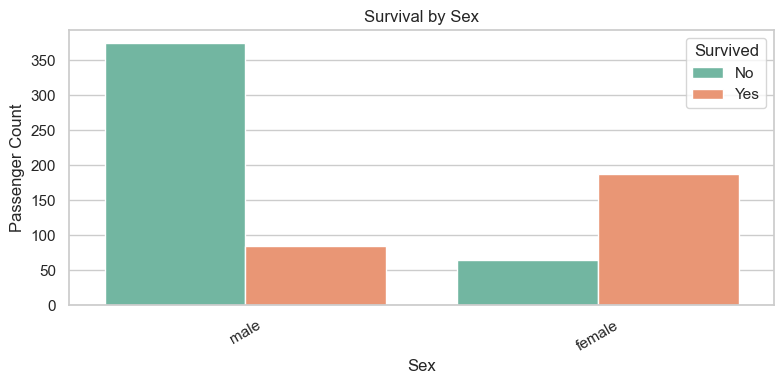

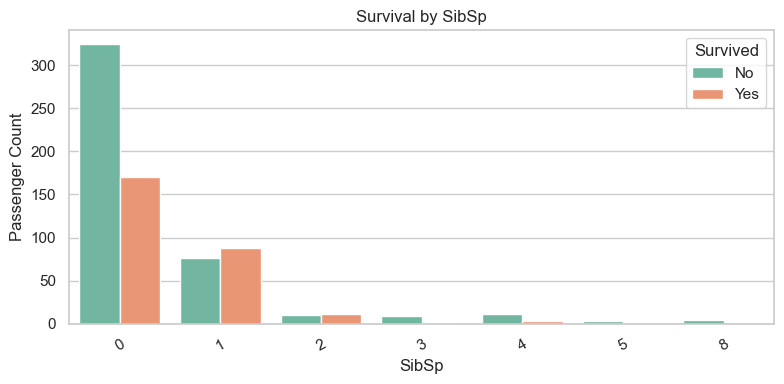

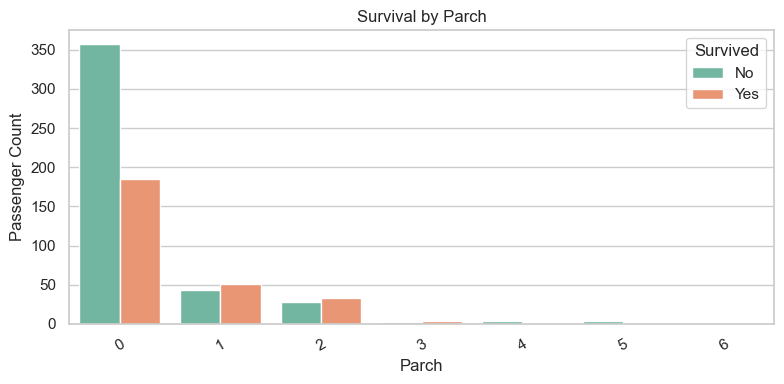

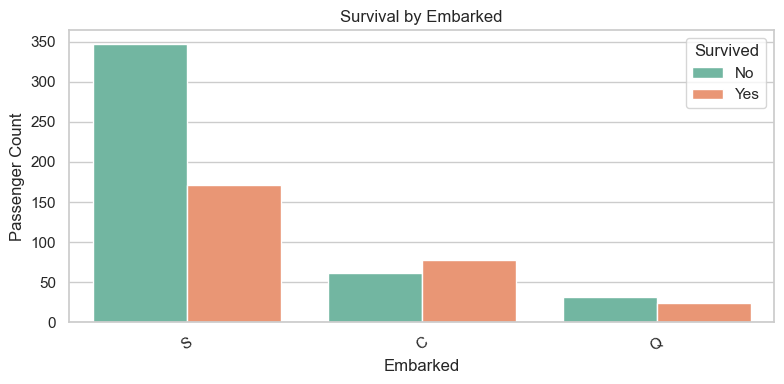

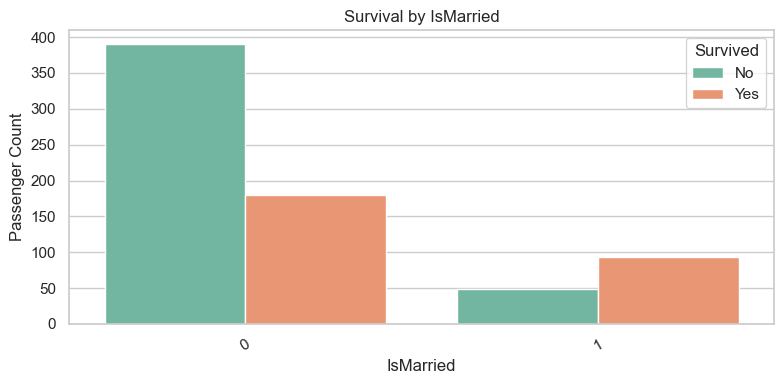

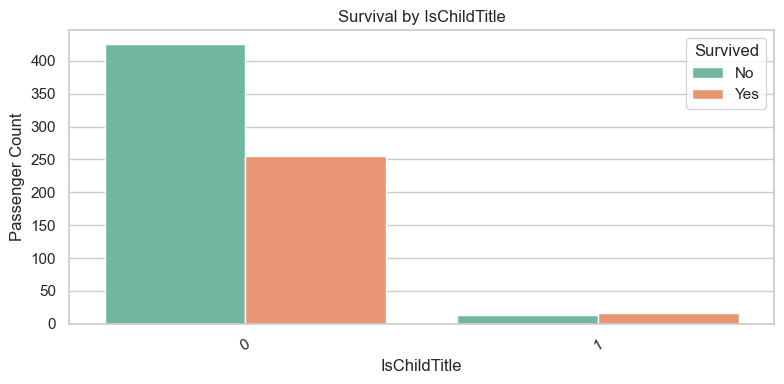

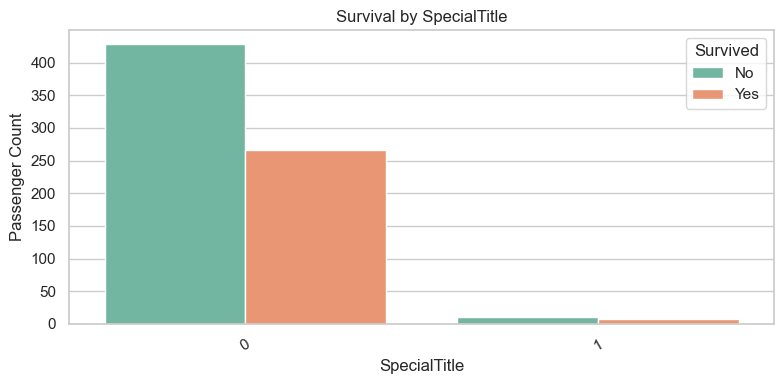

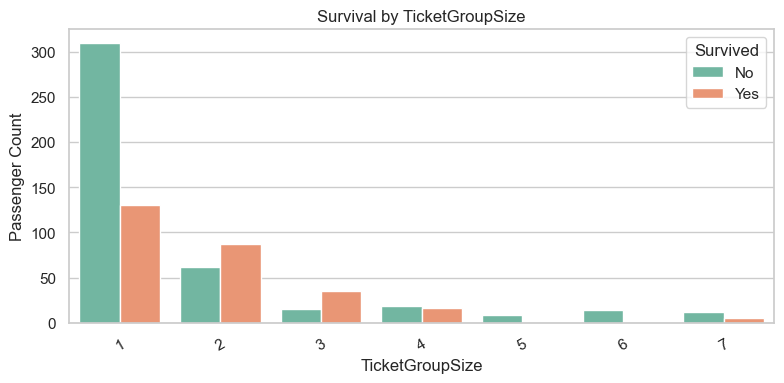

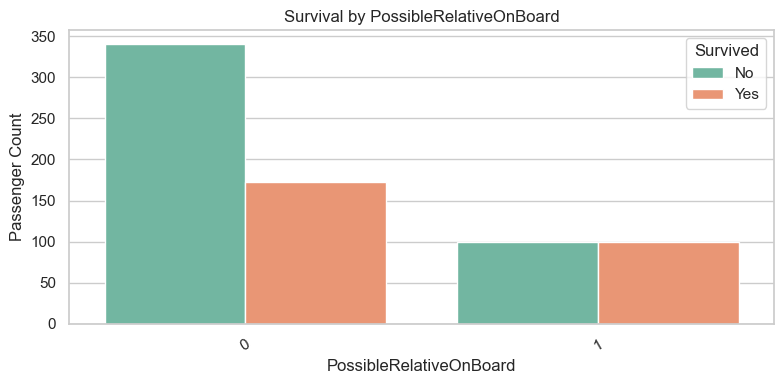

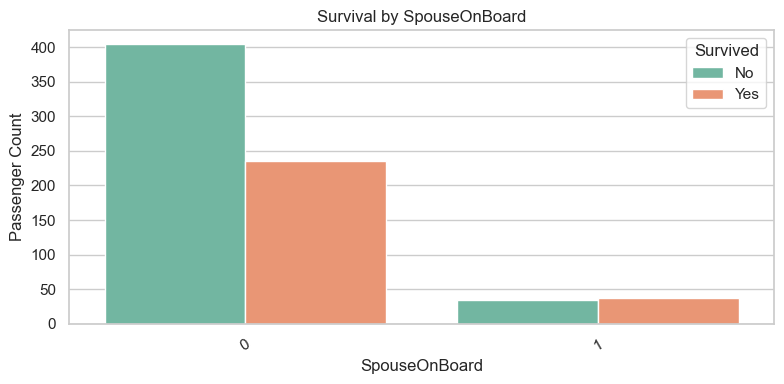

In [2131]:
for column in categorical_columns:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=train_df,
        x=column,
        hue="Survived",
        palette="Set2",
    )

    plt.title(f"Survival by {column}")
    plt.ylabel("Passenger Count")
    plt.legend(title="Survived", labels=["No", "Yes"])
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


The accompanying tables provide exact passenger counts and survival percentages, which are easier to compare than bar heights alone.


In [2132]:
for column in categorical_columns:
    summary = train_df.groupby(column, dropna=False).agg(
        PassengerCount=("Survived", "size"),
        SurvivalRate=("Survived", "mean"),
    )

    summary["SurvivalRate"] *= 100

    print(f"\nSurvival by {column}")
    display(summary.round(2))



Survival by Pclass


,PassengerCount,SurvivalRate
Pclass,,
1,171,64.91
2,150,44.67
3,391,24.30



Survival by Sex


,PassengerCount,SurvivalRate
Sex,,
female,253,74.31
male,459,18.52



Survival by SibSp


...

,PassengerCount,SurvivalRate
TicketGroupSize,,
1,439,29.61
2,149,58.39
3,50,70.00
4,34,47.06
5,9,0.00
6,14,0.00
7,17,29.41



Survival by PossibleRelativeOnBoard


,PassengerCount,SurvivalRate
PossibleRelativeOnBoard,,
0,513,33.72
1,199,50.25



Survival by SpouseOnBoard


,PassengerCount,SurvivalRate
SpouseOnBoard,,
0,639,36.78
1,73,52.05


## Correlation Matrix

The correlation matrix summarizes linear relationships between numeric features. Strong correlation does not prove causation, and low correlation does not rule out nonlinear importance.


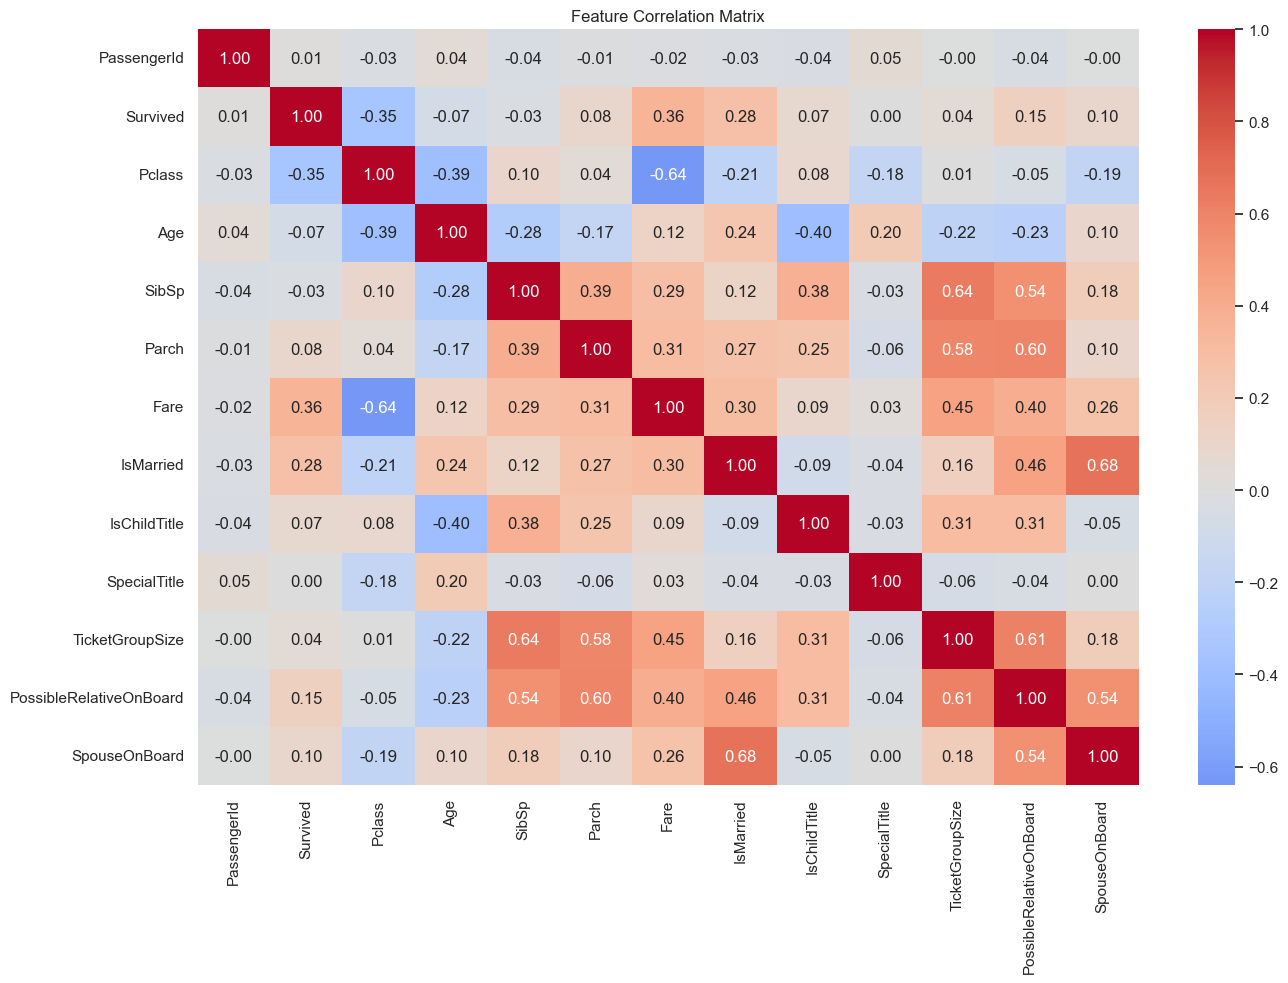

In [2133]:
numeric_df = train_df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


Correlations with `Survived` are isolated and sorted so the strongest positive and negative linear associations can be identified quickly.


,Correlation
Pclass,-0.348007
Age,-0.074464
SibSp,-0.026115
SpecialTitle,0.001809
PassengerId,0.011892
TicketGroupSize,0.043804
IsChildTitle,0.072386
Parch,0.084178
SpouseOnBoard,0.095319
PossibleRelativeOnBoard,0.152543


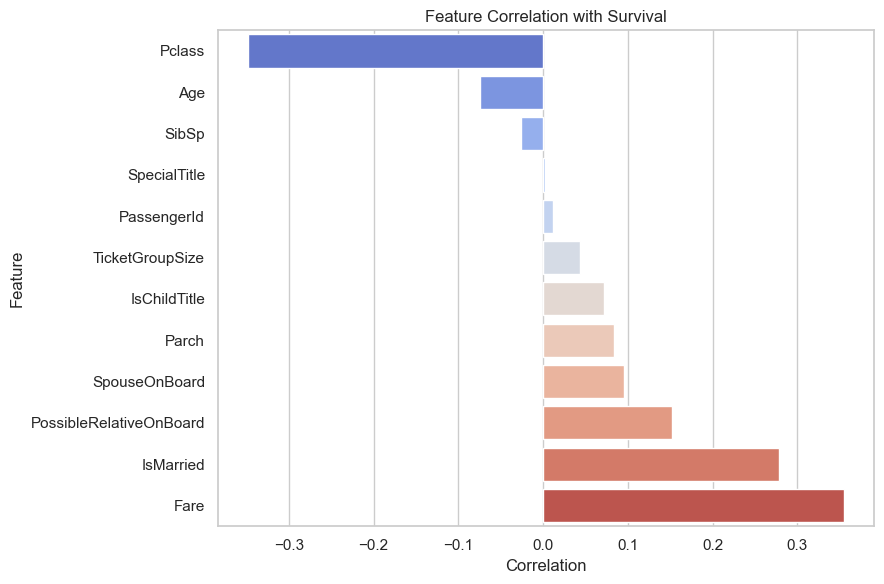

In [2134]:
survival_correlations = (
    correlation_matrix["Survived"]
    .drop("Survived")
    .sort_values()
)

display(survival_correlations.to_frame("Correlation"))

plt.figure(figsize=(9, 6))
sns.barplot(
    x=survival_correlations.values,
    y=survival_correlations.index,
    hue=survival_correlations.index,
    legend=False,
    palette="coolwarm",
)

plt.title("Feature Correlation with Survival")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 7. Final Feature Creation

Feature decisions made from training EDA must be applied identically to `train_df` and `val_df`. The validation set is transformed without examining its relationship with survival.

## Ideas for features:

- Age categories
- Young males aged 18–34 who have family on board


Age is divided into five ordered numeric categories. Numeric labels preserve the natural order from children to seniors.


In [2135]:
for df in [train_df, val_df]:
    df["AgeCategory"] = pd.cut(
        df["Age"],
        bins=[0, 12, 17, 34, 59, float("inf")],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True,
    ).astype(int)


### Combined age–sex category

Age and sex had a visibly combined relationship with survival. `AgeSexCategory` joins the age band and sex into one categorical interaction, such as `female_2` or `male_0`. It is kept as text so the model one-hot encodes each combination rather than treating the codes as a continuous measurement.


In [2136]:
for df in [train_df, val_df]:
    df["AgeSexCategory"] = (
        df["Sex"]
        + "_"
        + df["AgeCategory"].astype(str)
    )


`MaleAge18To34` identifies male passengers aged 18–34 who travelled with at least one parent, child, sibling or spouse according to `Parch` and `SibSp`.


In [2137]:
for df in [train_df, val_df]:
    df["MaleAge18To34"] = (
        (df["Sex"] == "male")
        & df["Age"].between(18, 34, inclusive="both")
        & ((df["Parch"] > 0) | (df["SibSp"] > 0))
    ).astype(int)


Based on the initial EDA, the selected low-value or identifier columns are removed from both datasets so their schemas remain identical.


In [2138]:
final_columns_to_remove = [
    "SpecialTitle",
    "PassengerId",
    "Embarked",
]

train_df.drop(columns=final_columns_to_remove, inplace=True)
val_df.drop(columns=final_columns_to_remove, inplace=True)

assert train_df.columns.tolist() == val_df.columns.tolist()


# 8. Pairwise Numeric Interaction Screening

A product of two columns can represent an interaction that neither feature captures alone. Every pair of numeric predictors is tested using cross-validation on `train_df` only. This keeps the separate validation set out of feature selection.

The screening uses the same type of preprocessing and Random Forest model as the baseline. A product is retained only when it improves mean cross-validation accuracy by more than `0.005`. Rejected products are never added permanently.


The candidate list excludes `Survived` and includes every pair of remaining numeric predictors. String categories such as `Sex` continue to be handled by one-hot encoding rather than multiplication.


In [2139]:
from itertools import combinations

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

interaction_X = train_df.drop(columns="Survived")
interaction_y = train_df["Survived"]

numeric_feature_columns = interaction_X.select_dtypes(
    include="number"
).columns.tolist()

feature_pairs = list(combinations(numeric_feature_columns, 2))

print("Numeric features:", len(numeric_feature_columns))
print("Products to test:", len(feature_pairs))


Numeric features: 12
Products to test: 66


A helper builds a fresh pipeline for each candidate dataset. Three stratified folds provide a concise initial screen while keeping the survival proportion similar in every fold.


In [2140]:
def build_interaction_model(X):
    categorical = X.select_dtypes(
        include=["object", "category"]
    ).columns

    preprocessing = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                categorical,
            )
        ],
        remainder="passthrough",
    )

    return Pipeline([
        ("preprocessor", preprocessing),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=20,
                max_depth=5,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ])


interaction_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


The baseline score is calculated without interaction products. Each candidate product is then added separately and evaluated against exactly the same cross-validation folds.


In [2141]:
baseline_interaction_score = cross_val_score(
    build_interaction_model(interaction_X),
    interaction_X,
    interaction_y,
    cv=interaction_cv,
    scoring="accuracy",
    n_jobs=-1,
).mean()

interaction_results = []

for first_column, second_column in feature_pairs:
    candidate_X = interaction_X.copy()
    feature_name = f"{first_column}_x_{second_column}"
    candidate_X[feature_name] = (
        candidate_X[first_column] * candidate_X[second_column]
    )

    candidate_score = cross_val_score(
        build_interaction_model(candidate_X),
        candidate_X,
        interaction_y,
        cv=interaction_cv,
        scoring="accuracy",
        n_jobs=-1,
    ).mean()

    interaction_results.append({
        "Feature": feature_name,
        "FirstColumn": first_column,
        "SecondColumn": second_column,
        "Accuracy": candidate_score,
        "Improvement": candidate_score - baseline_interaction_score,
    })

interaction_results = pd.DataFrame(interaction_results).sort_values(
    "Improvement",
    ascending=False,
)

print("Baseline CV accuracy:", round(baseline_interaction_score, 4))
display(interaction_results)


Baseline CV accuracy: 0.8217


,Feature,FirstColumn,SecondColumn,Accuracy,Improvement
52,IsChildTitle_x_PossibleRelativeOnBoard,IsChildTitle,PossibleRelativeOnBoard,0.837112,0.015444
24,SibSp_x_IsChildTitle,SibSp,IsChildTitle,0.837102,0.015434
51,IsChildTitle_x_TicketGroupSize,IsChildTitle,TicketGroupSize,0.835704,0.014035
39,Fare_x_IsChildTitle,Fare,IsChildTitle,0.834315,0.012647
27,SibSp_x_SpouseOnBoard,SibSp,SpouseOnBoard,0.834295,0.012627
...,...,...,...,...,...
13,Age_x_Fare,Age,Fare,0.823067,0.001399
49,IsMarried_x_AgeCategory,IsMarried,AgeCategory,0.823047,0.001379
0,Pclass_x_Age,Pclass,Age,0.821668,0.000000
40,Fare_x_TicketGroupSize,Fare,TicketGroupSize,0.820250,-0.001418


Only products exceeding the chosen improvement threshold are retained. The same formulas are applied to `val_df`; its labels are not used when selecting the products.


In [2142]:
INTERACTION_THRESHOLD = 0.005

kept_interactions = interaction_results[
    interaction_results["Improvement"] > INTERACTION_THRESHOLD
].copy()

for _, interaction in kept_interactions.iterrows():
    feature_name = interaction["Feature"]
    first_column = interaction["FirstColumn"]
    second_column = interaction["SecondColumn"]

    train_df[feature_name] = (
        train_df[first_column] * train_df[second_column]
    )
    val_df[feature_name] = (
        val_df[first_column] * val_df[second_column]
    )

print("Products retained:", len(kept_interactions))
display(kept_interactions)

assert train_df.columns.tolist() == val_df.columns.tolist()


Products retained: 43


,Feature,FirstColumn,SecondColumn,Accuracy,Improvement
52,IsChildTitle_x_PossibleRelativeOnBoard,IsChildTitle,PossibleRelativeOnBoard,0.837112,0.015444
24,SibSp_x_IsChildTitle,SibSp,IsChildTitle,0.837102,0.015434
51,IsChildTitle_x_TicketGroupSize,IsChildTitle,TicketGroupSize,0.835704,0.014035
39,Fare_x_IsChildTitle,Fare,IsChildTitle,0.834315,0.012647
27,SibSp_x_SpouseOnBoard,SibSp,SpouseOnBoard,0.834295,0.012627
23,SibSp_x_IsMarried,SibSp,IsMarried,0.834285,0.012617
28,SibSp_x_AgeCategory,SibSp,AgeCategory,0.832916,0.011248
2,Pclass_x_Parch,Pclass,Parch,0.832907,0.011238
35,Parch_x_SpouseOnBoard,Parch,SpouseOnBoard,0.832897,0.011228
30,Parch_x_Fare,Parch,Fare,0.832897,0.011228


# 9. Baseline Random Forest

A new 15% internal validation subset is created from the current training data. This subset supports initial model evaluation while the separately saved `val_df` remains untouched.


In [2143]:
model_train_df, model_val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["Survived"],
)

X_train = model_train_df.drop(columns="Survived")
y_train = model_train_df["Survived"]

X_val = model_val_df.drop(columns="Survived")
y_val = model_val_df["Survived"]

print("Training:", X_train.shape)
print("Internal validation:", X_val.shape)


Training: (605, 57)
Internal validation: (107, 57)


The preprocessing pipeline one-hot encodes any remaining categorical columns and passes numeric columns through unchanged. Keeping preprocessing inside the pipeline ensures the same transformation is used during fitting and prediction.


In [2144]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns,
        )
    ],
    remainder="passthrough",
)

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=20,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1,
        ),
    ),
])


The model is fitted on the internal training subset and evaluated using accuracy, precision, recall, F1-score and a confusion matrix.


Accuracy: 0.8411214953271028
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        66
           1       0.88      0.68      0.77        41

    accuracy                           0.84       107
   macro avg       0.85      0.81      0.82       107
weighted avg       0.85      0.84      0.84       107



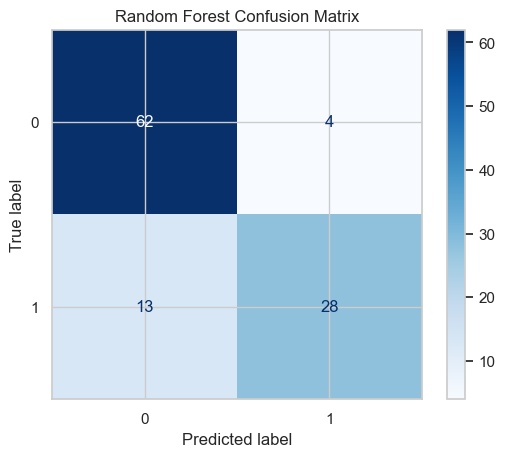

In [2145]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    cmap="Blues",
)

plt.title("Random Forest Confusion Matrix")
plt.show()


### Incorrect predictions

Misclassified validation passengers are collected with their predicted survival probabilities. Reviewing these cases may reveal patterns or groups the baseline model handles poorly.


In [2146]:
wrong_predictions = model_val_df.copy()
wrong_predictions["Predicted"] = y_pred
wrong_predictions["SurvivalProbability"] = model.predict_proba(X_val)[:, 1]

wrong_predictions = wrong_predictions[
    wrong_predictions["Survived"] != wrong_predictions["Predicted"]
]

display(
    wrong_predictions.sample(
        n=min(100, len(wrong_predictions)),
        random_state=42,
    )
)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,IsMarried,IsChildTitle,TicketGroupSize,...,IsChildTitle_x_AgeCategory,AgeCategory_x_MaleAge18To34,TicketGroupSize_x_MaleAge18To34,IsMarried_x_PossibleRelativeOnBoard,Fare_x_SpouseOnBoard,Parch_x_IsMarried,Pclass_x_MaleAge18To34,TicketGroupSize_x_AgeCategory,Predicted,SurvivalProbability
248,1,1,male,48.0,1,0,4.353231,1,0,3,...,0,0,0,1,4.353231,0,0,9,0,0.409313
6,1,3,male,26.0,0,0,4.051712,0,0,7,...,0,0,0,0,0.000000,0,0,14,0,0.209261
548,1,1,male,42.0,0,0,3.306429,0,0,1,...,0,0,0,0,0.000000,0,0,3,0,0.316957
705,0,3,female,18.0,0,0,2.212387,0,0,1,...,0,0,0,0,0.000000,0,0,2,1,0.614832
23,1,2,male,19.0,0,0,2.442347,0,0,1,...,0,0,0,0,0.000000,0,0,2,0,0.166231
267,1,1,male,40.0,0,0,3.465736,0,0,1,...,0,0,0,0,0.000000,0,0,3,0,0.316957
56,1,3,male,27.0,0,0,4.051712,0,0,7,...,0,0,0,0,0.000000,0,0,14,0,0.209261
266,1,3,male,27.0,0,0,2.107689,0,0,1,...,0,0,0,0,0.000000,0,0,2,0,0.104585
0,1,3,male,27.0,0,0,4.051712,0,0,7,...,0,0,0,0,0.000000,0,0,14,0,0.209261
671,0,3,female,21.0,2,2,3.566005,0,0,4,...,0,0,0,0,0.000000,0,0,8,1,0.522681


### Permutation feature importance

Permutation importance measures how much validation accuracy decreases when each original feature is shuffled. A larger positive value indicates that the model relies more strongly on that feature.


In [2147]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    model,
    X_val,
    y_val,
    scoring="accuracy",
    n_repeats=100,
    random_state=42,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": importance_result.importances_mean,
    "StandardDeviation": importance_result.importances_std,
}).sort_values("Importance", ascending=True)


The importance values are plotted with their variation across repeated shuffles. Features near or below zero may contribute little or may be redundant with other columns.


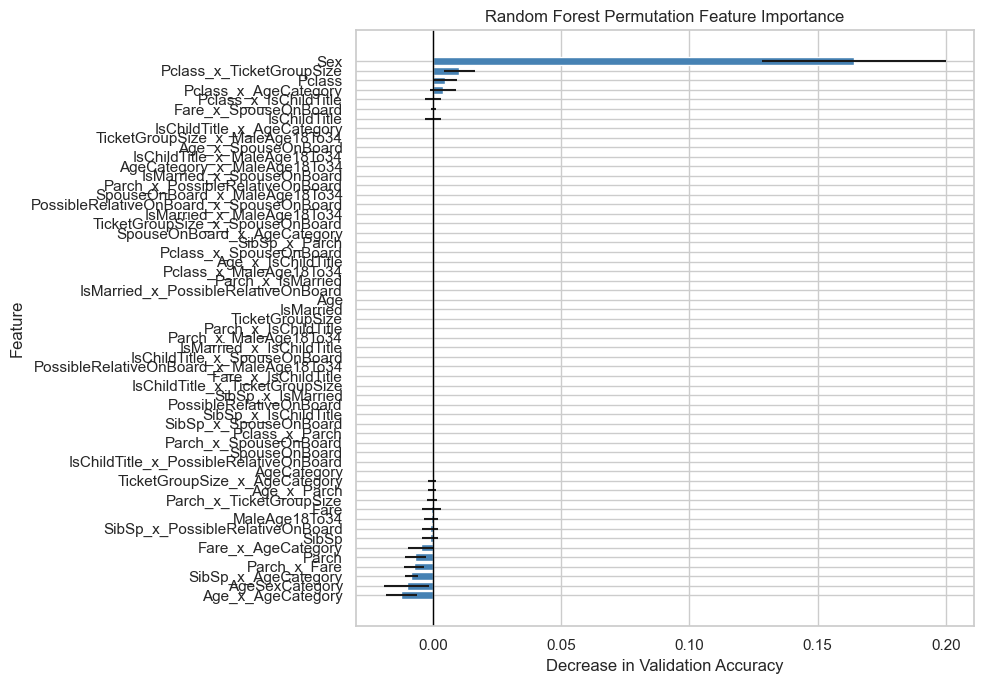

In [2148]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    xerr=feature_importance["StandardDeviation"],
    color="steelblue",
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Random Forest Permutation Feature Importance")
plt.xlabel("Decrease in Validation Accuracy")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Testing removal of low-importance features

Negative permutation importance suggests that a feature may be noisy, redundant, or unstable for this model. These columns are selected as removal candidates, but the reduced model must still be compared against the same internal validation subset.


In [2149]:
features_to_remove = feature_importance.loc[
    feature_importance["Importance"] < 0,
    "Feature"
].tolist()

print("Features to test removing:", features_to_remove)

Features to test removing: ['Age_x_AgeCategory', 'AgeSexCategory', 'SibSp_x_AgeCategory', 'Parch_x_Fare', 'Parch', 'Fare_x_AgeCategory', 'SibSp', 'SibSp_x_PossibleRelativeOnBoard', 'MaleAge18To34', 'Fare', 'Parch_x_TicketGroupSize', 'Age_x_Parch', 'TicketGroupSize_x_AgeCategory']


The candidate features are removed from copies of the internal training and validation matrices. The original data remains available until the reduced model proves at least as effective.


In [2150]:
X_train_reduced = X_train.drop(
    columns=features_to_remove
)

X_val_reduced = X_val.drop(
    columns=features_to_remove
)

A new preprocessing and Random Forest pipeline is created because removing columns can change which categorical inputs need encoding.


In [2151]:
categorical_columns_reduced = (
    X_train_reduced
    .select_dtypes(include=["object", "category"])
    .columns
)

preprocessor_reduced = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns_reduced
        )
    ],
    remainder="passthrough"
)

reduced_model = Pipeline([
    ("preprocessor", preprocessor_reduced),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=20,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    )
])

The reduced model is evaluated on the same held-out internal rows. This makes the before-and-after accuracy comparison fair.


In [2152]:
reduced_model.fit(X_train_reduced, y_train)

reduced_pred = reduced_model.predict(X_val_reduced)

original_accuracy = accuracy_score(y_val, y_pred)
reduced_accuracy = accuracy_score(y_val, reduced_pred)

print("Original accuracy:", original_accuracy)
print("Reduced accuracy: ", reduced_accuracy)
print("Difference:       ", reduced_accuracy - original_accuracy)

Original accuracy: 0.8411214953271028
Reduced accuracy:  0.8598130841121495
Difference:        0.01869158878504673


The candidate features are removed only if the reduced model matches or improves the original internal-validation accuracy. Otherwise, the original feature set is retained. The same decision is applied to both `train_df` and `val_df`.


In [2153]:
if reduced_accuracy >= original_accuracy:
    train_df.drop(columns=features_to_remove, inplace=True)
    val_df.drop(columns=features_to_remove, inplace=True)
    print("Removed features:", features_to_remove)
else:
    features_to_remove = []
    print("No features removed because validation accuracy did not improve.")

assert train_df.columns.tolist() == val_df.columns.tolist()


Removed features: ['Age_x_AgeCategory', 'AgeSexCategory', 'SibSp_x_AgeCategory', 'Parch_x_Fare', 'Parch', 'Fare_x_AgeCategory', 'SibSp', 'SibSp_x_PossibleRelativeOnBoard', 'MaleAge18To34', 'Fare', 'Parch_x_TicketGroupSize', 'Age_x_Parch', 'TicketGroupSize_x_AgeCategory']


The remaining training columns are displayed as a final schema check before the cleaned validation dataset is saved.


In [2154]:
train_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'IsMarried', 'IsChildTitle',
       'TicketGroupSize', 'PossibleRelativeOnBoard', 'SpouseOnBoard',
       'AgeCategory', 'IsChildTitle_x_PossibleRelativeOnBoard',
       'SibSp_x_IsChildTitle', 'IsChildTitle_x_TicketGroupSize',
       'Fare_x_IsChildTitle', 'SibSp_x_SpouseOnBoard', 'SibSp_x_IsMarried',
       'Pclass_x_Parch', 'Parch_x_SpouseOnBoard',
       'PossibleRelativeOnBoard_x_MaleAge18To34', 'Parch_x_MaleAge18To34',
       'IsChildTitle_x_SpouseOnBoard', 'IsMarried_x_IsChildTitle',
       'Parch_x_IsChildTitle', 'TicketGroupSize_x_SpouseOnBoard',
       'Age_x_IsChildTitle', 'Pclass_x_SpouseOnBoard', 'SibSp_x_Parch',
       'Pclass_x_AgeCategory', 'Pclass_x_IsChildTitle', 'Age_x_SpouseOnBoard',
       'SpouseOnBoard_x_AgeCategory', 'SpouseOnBoard_x_MaleAge18To34',
       'Parch_x_PossibleRelativeOnBoard', 'IsMarried_x_MaleAge18To34',
       'PossibleRelativeOnBoard_x_SpouseOnBoard', 'IsMarried_x_SpouseOnBoard',
       'Pclass_x_Ticket

# 10. EDA Conclusions

The EDA established the main patterns and data-quality decisions needed for modeling:

- Survival is associated strongly with sex and passenger class.
- Age contains substantial missingness, so it was imputed using title and class statistics learned only from training data.
- `Cabin` was removed because most entries were missing, while `Embarked` was completed using the training mode.
- Fare was log-transformed to reduce its strong right skew.
- Family, title, ticket-group, age-group, age–sex interaction and high-probability spouse information were explored as engineered predictors.
- Pairwise numeric products were retained only when they improved cross-validated training performance.
- Permutation importance was used as a model-specific diagnostic, and negatively important features were removed only after the reduced model improved on the same internal validation subset.

The Random Forest is an exploratory baseline rather than the final submission model. The assignment requires the final classifier to be implemented and trained in PyTorch, with tuning performed in the standalone `train.py` workflow. The separate `val_df` remains reserved for later evaluation and is not used to guide further EDA decisions.


### Save the final transformed validation set

The validation set is saved only after all accepted feature creation and removal steps have been applied. It is named `validation.csv` to distinguish it clearly from Kaggle's official `test.csv`, which is not used in this assignment. `index=False` prevents an extra index column from appearing in the CSV.


In [2155]:
val_df.to_csv(DATA_DIR / "validation.csv", index=False)
